<a href="https://colab.research.google.com/github/RayCharles8/ML-Project/blob/main/CGNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [109]:
import os
import sys
import numpy as np
import pandas as pd
import random
from tqdm import tqdm

!pip install torch-geometric torch-cluster pymatgen

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data, Dataset, DataLoader, Batch
from torch_geometric.nn import CGConv, global_mean_pool, GATConv, Set2Set, MessagePassing
from torch_geometric.explain import GNNExplainer
from torch_cluster import radius_graph
from torch_geometric.utils import scatter
from pymatgen.io.cif import CifParser
from pymatgen.core import Structure, Element
from torch.utils.data import Subset
from torch_geometric.explain.config import (
    ModelConfig
)


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, roc_curve

import matplotlib.pyplot as plt
import seaborn as sns

!pip install pysr
from pysr import PySRRegressor

import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Define paths
BASE_DIR = "/content/drive/MyDrive/IML Project"

DATA_PATH = os.path.join(BASE_DIR, "Dataset.csv")
CIF_DIR = os.path.join(BASE_DIR)

GRAPH_DIR = os.path.join(BASE_DIR, "graphs")
os.makedirs(GRAPH_DIR, exist_ok=True)

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cuda


# Load Data

In [11]:
df = pd.read_csv(DATA_PATH)
df.head()

,mp_material_id,mp_formula,spacegroup,spacegroup_number,number of atoms,Band Gap,a,b,c,alpha,beta,gamma,Z,electronegativity,Topological Label,label,cif
0,mp-573069,Ba2CaTl2(CuO4)2,I4/mmm,139,30,0.0000,3.950204,3.950204,30.646282,90.0,90.000000,90.0,27.733333,2.489333,Trivial,0,cifs/mp-573069.cif
1,mp-1193609,PH8IN4,P4/nbm,125,28,1.1111,7.704433,7.704433,7.932095,90.0,90.000000,90.0,7.428571,2.472143,TI,1,cifs/mp-1193609.cif
2,mp-21420,Nd(MnGe)2,I4/mmm,139,10,0.0000,4.173254,4.173254,11.115354,90.0,90.000000,90.0,34.800000,1.652000,TI,1,cifs/mp-21420.cif
3,mp-4920,Nd(GeRh)2,I4/mmm,139,10,0.0000,4.157947,4.157947,10.458460,90.0,90.000000,90.0,42.800000,1.944000,TI,1,cifs/mp-4920.cif
4,mp-15827,Ho2Ge2Os,C2/m,12,20,0.0000,10.699596,4.275589,10.037210,90.0,118.097977,90.0,54.800000,1.736000,TI,1,cifs/mp-15827.cif


In [12]:
print("Total samples:", len(df))

Total samples: 9668


In [13]:
#Check class balance
print("\nLabel distribution:")
print(df['label'].value_counts())


Label distribution:
label
0    5198
1    4470
Name: count, dtype: int64


In [14]:
# Build absolute CIF paths
df['cif_path'] = df['cif'].apply(lambda x: os.path.join(CIF_DIR, x))

# Quick check
print(df[['cif', 'cif_path']].head())

                   cif                                           cif_path
0   cifs/mp-573069.cif  /content/drive/MyDrive/IML Project/cifs/mp-573...
1  cifs/mp-1193609.cif  /content/drive/MyDrive/IML Project/cifs/mp-119...
2    cifs/mp-21420.cif  /content/drive/MyDrive/IML Project/cifs/mp-214...
3     cifs/mp-4920.cif  /content/drive/MyDrive/IML Project/cifs/mp-492...
4    cifs/mp-15827.cif  /content/drive/MyDrive/IML Project/cifs/mp-158...


In [15]:
os.path.exists(df['cif_path'].iloc[0])

True

# Data Splitting

In [16]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df['label'],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['label'],
    random_state=SEED
)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Train: 6767 | Val: 1450 | Test: 1451


# Feature Extraction

In [17]:
# Node features
def get_atom_features(element):
    el = Element(element)

    return [
        el.Z,
        el.X if el.X else 0,
        el.atomic_radius if el.atomic_radius else 0,
        el.group if el.group else 0,
        el.row if el.row else 0
    ]

# Global Features
def extract_global_features(row, structure):
    return [
        row['spacegroup_number'],
        row['number of atoms'],
        row['a'], row['b'], row['c'],
        row['alpha'], row['beta'], row['gamma'],
        row['Z'],
        row['electronegativity'],
        row['Band Gap'],
        structure.volume,
        structure.density,
        len(structure.composition.elements)
    ]

# Train Features for Scaling

In [18]:
# COLLECT TRAIN FEATURES
node_samples = []
edge_samples = []
global_samples = []

cutoff = 6.0

for _, row in train_df.iterrows():
    try:
        structure = Structure.from_file(row['cif_path'])

        # Node features
        for site in structure:
            node_samples.append(get_atom_features(site.specie.symbol))

        # Edge features (distance)
        for i, site in enumerate(structure):
            neighbors = structure.get_neighbors(site, cutoff)
            for n in neighbors:
                edge_samples.append([n.nn_distance])

        # Global features
        global_samples.append(extract_global_features(row, structure))

    except Exception as e:
        print(f"Error processing {row['cif_path']} | {e}")

# Convert safely
node_samples = np.array(node_samples)
edge_samples = np.array(edge_samples)
global_samples = np.array(global_samples)

print("Node shape:", node_samples.shape)
print("Edge shape:", edge_samples.shape)
print("Global shape:", global_samples.shape)

Node shape: (211448, 5)
Edge shape: (11843614, 1)
Global shape: (6767, 14)


In [19]:
# SCALING
node_scaler = StandardScaler().fit(node_samples)
edge_scaler = StandardScaler().fit(edge_samples)
global_scaler = StandardScaler().fit(global_samples)

# Gaussian Expansion

In [20]:
# GAUSSIAN EXPANSION

class GaussianDistance:
    def __init__(self, dmin=0, dmax=6, step=0.2):
        self.filter = np.arange(dmin, dmax + step, step)
        self.var = step

    def expand(self, distances):
        return np.exp(-(distances[..., np.newaxis] - self.filter)**2 / self.var**2)

gaussian_expansion = GaussianDistance()

# Building Graphs

In [21]:
def build_graph(row):
    structure = Structure.from_file(row['cif_path'])

    # NODE FEATURES
    node_feat = [get_atom_features(site.specie.symbol) for site in structure]
    node_feat = node_scaler.transform(node_feat)
    x = torch.tensor(node_feat, dtype=torch.float)

    # POSITIONS
    pos = torch.tensor(structure.cart_coords, dtype=torch.float)

    # EDGES
    edge_index = []
    edge_attr = []
    cutoff = 6.0

    for i, site in enumerate(structure):
        neighbors = structure.get_neighbors(site, cutoff)
        for n in neighbors:
            j = n.index
            dist = n.nn_distance

            edge_index.append([i, j])
            edge_attr.append([dist])

    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()

    edge_attr = np.array(edge_attr)
    edge_attr = edge_scaler.transform(edge_attr)
    edge_attr = gaussian_expansion.expand(edge_attr.squeeze())
    edge_attr = torch.tensor(edge_attr, dtype=torch.float)

    # GLOBAL FEATURES
    global_feat = extract_global_features(row, structure)
    global_feat = global_scaler.transform([global_feat])
    u = torch.tensor(global_feat, dtype=torch.float)

    # LABEL
    y = torch.tensor([row['label']], dtype=torch.float)

    data = Data(
        x=x,
        edge_index=edge_index,
        edge_attr=edge_attr,
        y=y,
        pos=pos
    )

    data.u = u
    return data

In [22]:
def build_and_save(df_split, split_name):
    print(f"Building {split_name} graphs")

    save_dir = os.path.join(GRAPH_DIR, split_name)
    os.makedirs(save_dir, exist_ok=True)

    for _, row in tqdm(df_split.iterrows(), total=len(df_split)):
        graph_path = os.path.join(save_dir, f"{row['mp_material_id']}.pt")

        if os.path.exists(graph_path):
            continue

        try:
            graph = build_graph(row)
            torch.save(graph, graph_path)
        except Exception as e:
            print(f"Error: {row['mp_material_id']} | {e}")


# BUILD GRAPHS PER SPLIT
build_and_save(train_df, "Train")
build_and_save(val_df, "Val")
build_and_save(test_df, "Test")

Building Train graphs


100%|██████████| 6767/6767 [00:25<00:00, 265.71it/s] 


Building Val graphs


100%|██████████| 1450/1450 [00:00<00:00, 2581.60it/s]


Building Test graphs


100%|██████████| 1451/1451 [00:00<00:00, 2643.42it/s]


# CharlesCGCNN Model

In [23]:
class CharlesCGCNN(nn.Module):
    def __init__(self, node_dim, edge_dim, global_dim, hidden_dim=128, dropout=0.2):
        super(CharlesCGCNN, self).__init__()

        # Embeddings
        self.node_emb = nn.Linear(node_dim, hidden_dim)
        self.global_emb = nn.Linear(global_dim, hidden_dim)

        # CGCNN Layers
        self.conv1 = CGConv(hidden_dim, dim=edge_dim)
        self.conv2 = CGConv(hidden_dim, dim=edge_dim)
        self.conv3 = CGConv(hidden_dim, dim=edge_dim)

        # Dropout
        self.dropout = nn.Dropout(dropout)

        # Fully Connected Layers
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, data):
        x, edge_index, edge_attr, batch = data.x, data.edge_index, data.edge_attr, data.batch
        u = data.u  # global features

        # Embedding
        x = self.node_emb(x)
        u = self.global_emb(u)

        # CGCNN Layers (with gating)
        x = F.relu(self.conv1(x, edge_index, edge_attr))
        x = self.dropout(x)

        x = F.relu(self.conv2(x, edge_index, edge_attr))
        x = self.dropout(x)

        x = F.relu(self.conv3(x, edge_index, edge_attr))

        # Pooling
        x = global_mean_pool(x, batch)

        # Combine with global features
        combined = torch.cat([x, u], dim=1)

        # Final prediction
        out = self.fc(combined)

        return out

In [24]:
# Initialize model
model = CharlesCGCNN(
    node_dim=5,
    edge_dim=31,
    global_dim=14
).to(device)

In [25]:
# Training Configuration
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5
)

In [26]:
# Graph Dataset Loader
import torch
import torch.serialization
from torch_geometric.data.data import Data, DataEdgeAttr

# allow PyG objects
torch.serialization.add_safe_globals([Data, DataEdgeAttr])


class CrystalDataset(Dataset):
    def __init__(self, graph_dir):
        super().__init__()
        self.graph_dir = graph_dir

        self.files = sorted([
            f for f in os.listdir(graph_dir)
            if f.endswith(".pt")
        ])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        path = os.path.join(self.graph_dir, self.files[idx])

        data = torch.load(
            path,
            map_location="cpu",
            weights_only=False
        )

        return data

In [27]:
train_dataset = CrystalDataset(os.path.join(GRAPH_DIR, "Train"))
val_dataset   = CrystalDataset(os.path.join(GRAPH_DIR, "Val"))
test_dataset  = CrystalDataset(os.path.join(GRAPH_DIR, "Test"))

In [28]:
# Data Loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32)
test_loader  = DataLoader(test_dataset, batch_size=32)

In [29]:
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Train: 6767 | Val: 1450 | Test: 1451


# Training Loop

In [30]:
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5
)

# Tracking
train_losses = []
val_losses = []
val_f1_scores = []
val_roc_scores = []

In [31]:
# training function
def train_epoch(loader):
    model.train()
    total_loss = 0

    for data in loader:
        data = data.to(device)

        optimizer.zero_grad()

        out = model(data)

        # Ensure correct shape
        y = data.y.float().view(-1, 1)

        loss = criterion(out, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [32]:
# validation function
def eval_epoch(loader):
    model.eval()
    total_loss = 0
    preds, labels = [], []

    with torch.no_grad():
        for data in loader:
            data = data.to(device)

            out = model(data)

            y = data.y.float().view(-1, 1)
            loss = criterion(out, y)

            total_loss += loss.item()

            probs = torch.sigmoid(out)

            preds.append(probs.cpu())
            labels.append(y.cpu())

    preds = torch.cat(preds).numpy().flatten()
    labels = torch.cat(labels).numpy().flatten()

    binary = (preds > 0.5).astype(int)

    f1 = f1_score(labels, binary)
    roc = roc_auc_score(labels, preds)

    return total_loss / len(loader), f1, roc

In [33]:
# training loop
best_val_loss = float('inf')
patience = 15
counter = 0

EPOCHS = 100

for epoch in range(1, EPOCHS + 1):

    train_loss = train_epoch(train_loader)
    val_loss, val_f1, val_roc = eval_epoch(val_loader)

    scheduler.step(val_loss)

    # Store metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_f1_scores.append(val_f1)
    val_roc_scores.append(val_roc)

    print(f"Epoch {epoch:03d} | Train: {train_loss:.4f} | Val: {val_loss:.4f} | F1: {val_f1:.4f} | ROC: {val_roc:.4f}")

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_model.pt")
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered.")
            break

Epoch 001 | Train: 32.4684 | Val: 1.1451 | F1: 0.6350 | ROC: 0.7123
Epoch 002 | Train: 1.7152 | Val: 0.9493 | F1: 0.5980 | ROC: 0.7203
Epoch 003 | Train: 0.7240 | Val: 0.7464 | F1: 0.6892 | ROC: 0.7668
Epoch 004 | Train: 0.7443 | Val: 0.5973 | F1: 0.6191 | ROC: 0.8033
Epoch 005 | Train: 0.9798 | Val: 0.7104 | F1: 0.6498 | ROC: 0.7844
Epoch 006 | Train: 0.6149 | Val: 0.6922 | F1: 0.6406 | ROC: 0.8129
Epoch 007 | Train: 0.5173 | Val: 0.5550 | F1: 0.7631 | ROC: 0.8303
Epoch 008 | Train: 0.5111 | Val: 0.5134 | F1: 0.7617 | ROC: 0.8429
Epoch 009 | Train: 0.5149 | Val: 0.5169 | F1: 0.7677 | ROC: 0.8463
Epoch 010 | Train: 0.4820 | Val: 0.6267 | F1: 0.7043 | ROC: 0.8305
Epoch 011 | Train: 0.4829 | Val: 0.4957 | F1: 0.7698 | ROC: 0.8563
Epoch 012 | Train: 0.5059 | Val: 0.5125 | F1: 0.7678 | ROC: 0.8508
Epoch 013 | Train: 0.4837 | Val: 0.4842 | F1: 0.7897 | ROC: 0.8582
Epoch 014 | Train: 0.4745 | Val: 0.4846 | F1: 0.7947 | ROC: 0.8617
Epoch 015 | Train: 0.4935 | Val: 0.4751 | F1: 0.7803 | ROC: 0

In [34]:
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

# Evaluation

In [35]:
def evaluate_model(loader, name="Test"):
    model.eval()
    preds, labels_list = [], []

    with torch.no_grad():
        for data in loader:
            data = data.to(device)

            out = model(data)
            probs = torch.sigmoid(out)

            preds.append(probs.cpu())
            labels_list.append(data.y.cpu())

    probs = torch.cat(preds).numpy().flatten()
    labels = torch.cat(labels_list).numpy().flatten()

    binary = (probs > 0.5).astype(int)

    print(f"\n{name} Performance:")
    print(f"Accuracy : {accuracy_score(labels, binary):.4f}")
    print(f"F1-score : {f1_score(labels, binary):.4f}")
    print(f"ROC-AUC  : {roc_auc_score(labels, probs):.4f}")
    print(classification_report(labels, binary))

    return labels, probs, binary

In [122]:
# load best model
model.load_state_dict(torch.load("best_model.pt"))
labels, probs, binary = evaluate_model(test_loader)


Test Performance:
Accuracy : 0.8642
F1-score : 0.8569
ROC-AUC  : 0.9304
              precision    recall  f1-score   support

         0.0       0.89      0.85      0.87       780
         1.0       0.84      0.88      0.86       671

    accuracy                           0.86      1451
   macro avg       0.86      0.87      0.86      1451
weighted avg       0.87      0.86      0.86      1451



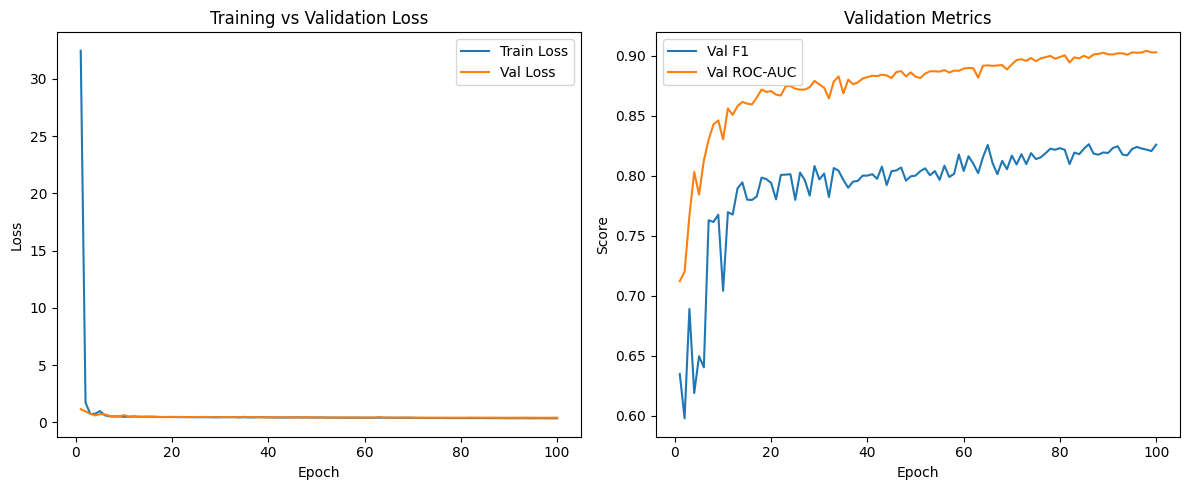

In [37]:
# training curves and validation metrics
epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 5))

# LOSS
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label="Train Loss")
plt.plot(epochs_range, val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

# METRICS
plt.subplot(1, 2, 2)
plt.plot(epochs_range, val_f1_scores, label="Val F1")
plt.plot(epochs_range, val_roc_scores, label="Val ROC-AUC")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Validation Metrics")
plt.legend()

plt.tight_layout()
plt.show()

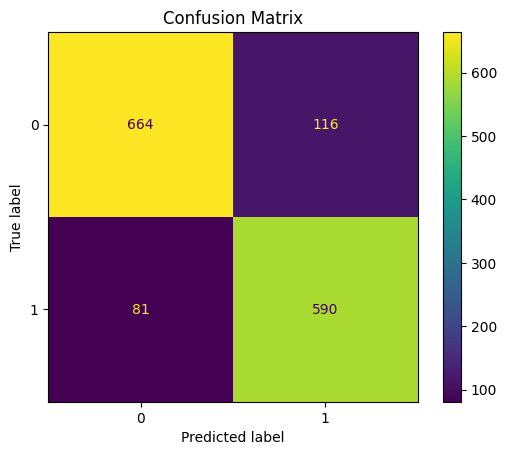

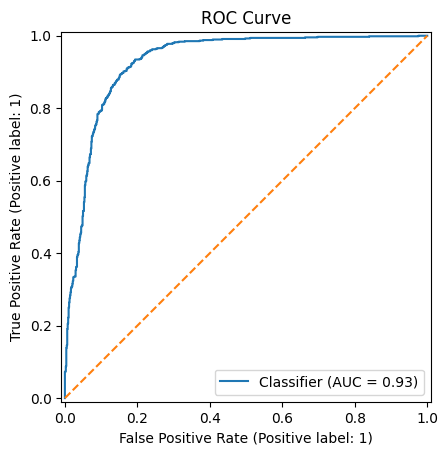

In [123]:
cm = confusion_matrix(labels, binary)
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix")
plt.show()


# Roc-Curve
RocCurveDisplay.from_predictions(labels_plot, probs_plot)
plt.title("ROC Curve")
plt.plot([0,1], [0,1], linestyle="--")

plt.show()

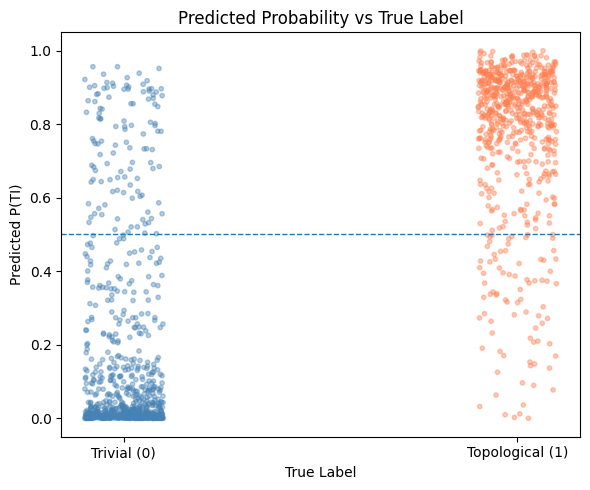

In [39]:
# scatter plot
plt.figure(figsize=(6, 5))

jitter = np.random.uniform(-0.1, 0.1, size=len(labels))

colors = ['steelblue' if l == 0 else 'coral' for l in labels]

plt.scatter(labels + jitter, probs, c=colors, alpha=0.4, s=10)

plt.axhline(0.5, linestyle='--', linewidth=1)

plt.xticks([0, 1], ['Trivial (0)', 'Topological (1)'])
plt.xlabel('True Label')
plt.ylabel('Predicted P(TI)')
plt.title('Predicted Probability vs True Label')

plt.tight_layout()
plt.show()

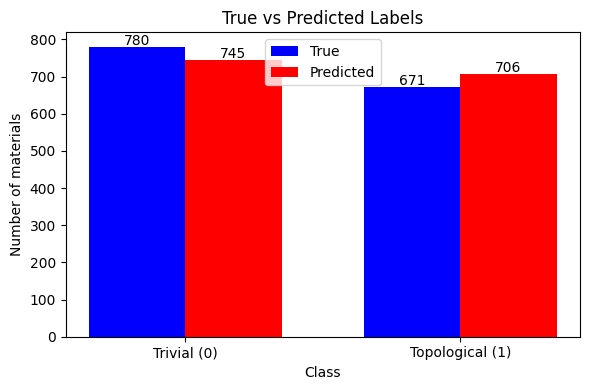

In [40]:
categories = ['Trivial (0)', 'Topological (1)']

true_counts = [(labels == 0).sum(), (labels == 1).sum()]
pred_counts = [(binary == 0).sum(), (binary == 1).sum()]

x = np.arange(len(categories))
width = 0.35

plt.figure(figsize=(6, 4))

bars1 = plt.bar(x - width/2, true_counts, width, label='True', color='blue')
bars2 = plt.bar(x + width/2, pred_counts, width, label='Predicted', color='red')

for bar in list(bars1) + list(bars2):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(int(bar.get_height())), ha='center')

plt.xticks(x, categories)
plt.xlabel('Class')
plt.ylabel('Number of materials')
plt.title('True vs Predicted Labels')
plt.legend()

plt.tight_layout()
plt.show()

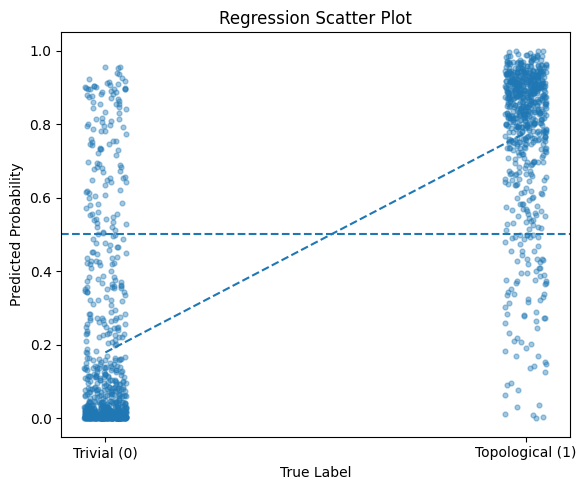

In [41]:
# Regresssion scatter plot
def plot_regression_scatter(labels, probs):
    plt.figure(figsize=(6,5))

    # jitter for visibility
    jitter = np.random.uniform(-0.05, 0.05, size=len(labels))

    plt.scatter(labels + jitter, probs, alpha=0.4, s=12)

    # regression trend line
    z = np.polyfit(labels, probs, 1)
    p = np.poly1d(z)
    plt.plot([0,1], p([0,1]), linestyle='--')

    plt.axhline(0.5, linestyle='--')

    plt.xticks([0,1], ['Trivial (0)', 'Topological (1)'])
    plt.xlabel("True Label")
    plt.ylabel("Predicted Probability")
    plt.title("Regression Scatter Plot")

    plt.tight_layout()
    plt.show()


# CALL
plot_regression_scatter(labels, probs)

# GAT MODEL

In [42]:
# GAT MODEL

class CharlesGAT(nn.Module):
    def __init__(
        self,
        node_dim,
        edge_dim,
        global_dim,
        hidden_dim=128,
        heads=4,
        dropout=0.2
    ):
        super(CharlesGAT, self).__init__()

        self.dropout = dropout
        self.hidden_dim = hidden_dim
        self.heads = heads

        # Node embedding
        self.node_emb = nn.Linear(node_dim, hidden_dim)

        # Global feature embedding
        self.global_emb = nn.Linear(global_dim, hidden_dim)

        # GAT Layers

        self.gat1 = GATConv(
            hidden_dim,
            hidden_dim,
            heads=heads,
            dropout=dropout,
            edge_dim=edge_dim
        )

        self.gat2 = GATConv(
            hidden_dim * heads,
            hidden_dim,
            heads=heads,
            dropout=dropout,
            edge_dim=edge_dim
        )

        self.gat3 = GATConv(
            hidden_dim * heads,
            hidden_dim,
            heads=1,
            concat=False,
            dropout=dropout,
            edge_dim=edge_dim
        )

        # Final Classifier

        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),

            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, data, return_attention=False):

        x = data.x
        edge_index = data.edge_index
        edge_attr = data.edge_attr
        batch = data.batch
        u = data.u

        # Embeddings

        x = self.node_emb(x)
        u = self.global_emb(u)

        # GAT Layer 1

        if return_attention:
            x, att1 = self.gat1(
                x,
                edge_index,
                edge_attr,
                return_attention_weights=True
            )
        else:
            x = self.gat1(x, edge_index, edge_attr)

        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        # GAT Layer 2

        if return_attention:
            x, att2 = self.gat2(
                x,
                edge_index,
                edge_attr,
                return_attention_weights=True
            )
        else:
            x = self.gat2(x, edge_index, edge_attr)

        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

      # GAT Layer 3

        if return_attention:
            x, att3 = self.gat3(
                x,
                edge_index,
                edge_attr,
                return_attention_weights=True
            )
        else:
            x = self.gat3(x, edge_index, edge_attr)

        x = F.relu(x)

        # Global Pooling

        x = global_mean_pool(x, batch)

        # Combine graph + global crystal features
        combined = torch.cat([x, u], dim=1)

        # Final prediction
        out = self.fc(combined)

        if return_attention:
            return out, [att1, att2, att3]

        return out

In [43]:
# INITIALIZE MODEL

gat_model = CharlesGAT(
    node_dim=5,
    edge_dim=31,
    global_dim=14,
    hidden_dim=128,
    heads=4,
    dropout=0.2
).to(device)

print(gat_model)

CharlesGAT(
  (node_emb): Linear(in_features=5, out_features=128, bias=True)
  (global_emb): Linear(in_features=14, out_features=128, bias=True)
  (gat1): GATConv(128, 128, heads=4)
  (gat2): GATConv(512, 128, heads=4)
  (gat3): GATConv(512, 128, heads=1)
  (fc): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=1, bias=True)
  )
)


# Training

In [44]:
# training configuration

# LOSS / OPTIMIZER / SCHEDULER

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    gat_model.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5
)

In [45]:
# TRAINING FUNCTION

def train_epoch_gat(loader):

    gat_model.train()

    total_loss = 0

    for data in loader:

        data = data.to(device)

        optimizer.zero_grad()

        out = gat_model(data)

        y = data.y.float().view(-1, 1)

        loss = criterion(out, y)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

# VALIDATION FUNCTION

def eval_epoch_gat(loader):

    gat_model.eval()

    total_loss = 0

    preds = []
    labels = []

    with torch.no_grad():

        for data in loader:

            data = data.to(device)

            out = gat_model(data)

            y = data.y.float().view(-1, 1)

            loss = criterion(out, y)

            total_loss += loss.item()

            probs = torch.sigmoid(out)

            preds.append(probs.cpu())
            labels.append(y.cpu())

    preds = torch.cat(preds).numpy().flatten()
    labels = torch.cat(labels).numpy().flatten()

    binary = (preds > 0.5).astype(int)

    f1 = f1_score(labels, binary)
    roc = roc_auc_score(labels, preds)

    return total_loss / len(loader), f1, roc

In [46]:
# TRAINING LOOP

train_losses_gat = []
val_losses_gat = []

val_f1_scores_gat = []
val_roc_scores_gat = []

best_val_loss = float('inf')

patience = 15
counter = 0

EPOCHS = 100

for epoch in range(1, EPOCHS + 1):

    train_loss = train_epoch_gat(train_loader)

    val_loss, val_f1, val_roc = eval_epoch_gat(val_loader)

    scheduler.step(val_loss)

    train_losses_gat.append(train_loss)
    val_losses_gat.append(val_loss)

    val_f1_scores_gat.append(val_f1)
    val_roc_scores_gat.append(val_roc)

    print(
        f"Epoch {epoch:03d} | "
        f"Train: {train_loss:.4f} | "
        f"Val: {val_loss:.4f} | "
        f"F1: {val_f1:.4f} | "
        f"ROC: {val_roc:.4f}"
    )

    # Save best model
    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            gat_model.state_dict(),
            "best_gat_model.pt"
        )

        counter = 0

    else:
        counter += 1

        if counter >= patience:
            print("Early stopping triggered.")
            break

Epoch 001 | Train: 0.4746 | Val: 0.4416 | F1: 0.7966 | ROC: 0.8770
Epoch 002 | Train: 0.4205 | Val: 0.4105 | F1: 0.8109 | ROC: 0.8882
Epoch 003 | Train: 0.4015 | Val: 0.4023 | F1: 0.8255 | ROC: 0.8957
Epoch 004 | Train: 0.3842 | Val: 0.3927 | F1: 0.8270 | ROC: 0.8998
Epoch 005 | Train: 0.3764 | Val: 0.3802 | F1: 0.8375 | ROC: 0.9069
Epoch 006 | Train: 0.3612 | Val: 0.3789 | F1: 0.8301 | ROC: 0.9099
Epoch 007 | Train: 0.3577 | Val: 0.4113 | F1: 0.8196 | ROC: 0.8973
Epoch 008 | Train: 0.3479 | Val: 0.3596 | F1: 0.8450 | ROC: 0.9195
Epoch 009 | Train: 0.3377 | Val: 0.3599 | F1: 0.8406 | ROC: 0.9175
Epoch 010 | Train: 0.3298 | Val: 0.3581 | F1: 0.8489 | ROC: 0.9211
Epoch 011 | Train: 0.3195 | Val: 0.3779 | F1: 0.8283 | ROC: 0.9170
Epoch 012 | Train: 0.3147 | Val: 0.3533 | F1: 0.8479 | ROC: 0.9237
Epoch 013 | Train: 0.3072 | Val: 0.3766 | F1: 0.8491 | ROC: 0.9218
Epoch 014 | Train: 0.3019 | Val: 0.3571 | F1: 0.8493 | ROC: 0.9242
Epoch 015 | Train: 0.2929 | Val: 0.3544 | F1: 0.8558 | ROC: 0.

In [124]:
# LOAD BEST MODEL

gat_model.load_state_dict(torch.load("best_gat_model.pt"))

# EVALUATION

def evaluate_gat(loader, name="Test"):

    gat_model.eval()

    preds = []
    labels_list = []

    with torch.no_grad():

        for data in loader:

            data = data.to(device)

            out = gat_model(data)

            probs = torch.sigmoid(out)

            preds.append(probs.cpu())
            labels_list.append(data.y.cpu())

    probs = torch.cat(preds).numpy().flatten()
    labels = torch.cat(labels_list).numpy().flatten()

    binary = (probs > 0.5).astype(int)

    print(f"\n{name} Performance:")
    print(f"Accuracy : {accuracy_score(labels, binary):.4f}")
    print(f"F1-score : {f1_score(labels, binary):.4f}")
    print(f"ROC-AUC  : {roc_auc_score(labels, probs):.4f}")

    print(classification_report(labels, binary))

    return labels, probs, binary


labels_gat, probs_gat, binary_gat = evaluate_gat(test_loader)


Test Performance:
Accuracy : 0.8332
F1-score : 0.8189
ROC-AUC  : 0.9044
              precision    recall  f1-score   support

         0.0       0.84      0.85      0.85       780
         1.0       0.82      0.82      0.82       671

    accuracy                           0.83      1451
   macro avg       0.83      0.83      0.83      1451
weighted avg       0.83      0.83      0.83      1451



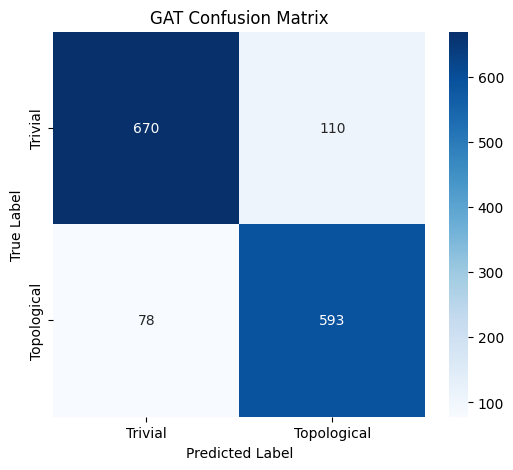

In [106]:
# CONFUSION MATRIX

cm = confusion_matrix(labels_gat, binary_gat)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Trivial", "Topological"],
    yticklabels=["Trivial", "Topological"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.title("GAT Confusion Matrix")

plt.show()

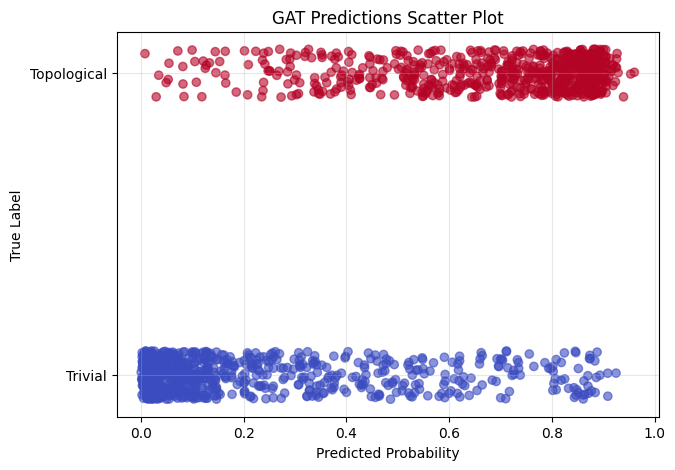

In [130]:
# SCATTER PLOT
import matplotlib.pyplot as plt
import numpy as np

# use correct variable names
labels = labels_gat
probs = probs_gat

# jitter for visibility
jitter = np.random.uniform(-0.08, 0.08, size=len(labels))

plt.figure(figsize=(7, 5))

scatter = plt.scatter(
    probs,
    labels + jitter,
    c=labels,
    cmap='coolwarm',
    alpha=0.6
)

plt.xlabel("Predicted Probability")
plt.ylabel("True Label")
plt.title("GAT Predictions Scatter Plot")

plt.yticks([0, 1], ["Trivial", "Topological"])

plt.grid(alpha=0.3)

plt.show()


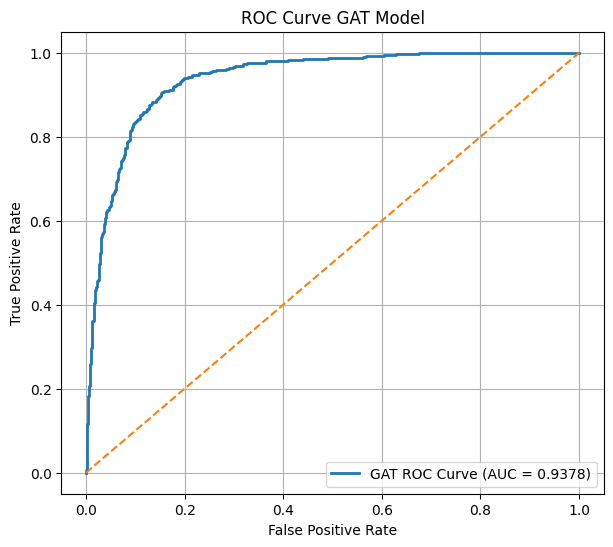

In [110]:
# ROC CURVE

fpr, tpr, thresholds = roc_curve(labels_gat, probs_gat)

auc_score = roc_auc_score(labels_gat, probs_gat)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"GAT ROC Curve (AUC = {auc_score:.4f})"
)

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve GAT Model")

plt.legend()

plt.grid(True)

plt.show()

# PySR

In [102]:
# BUILD FEATURE MATRIX FOR PySR

X_pysr = []
y_pysr = []

gat_model.eval()

with torch.no_grad():

    for data in test_loader:

        data = data.to(device)

        probs = torch.sigmoid(gat_model(data))

        for i in range(data.u.shape[0]):

            X_pysr.append(
                data.u[i].cpu().numpy()
            )

            y_pysr.append(
                probs[i].item()
            )

X_pysr = np.array(X_pysr)
y_pysr = np.array(y_pysr)

print("Feature matrix:", X_pysr.shape)
print("Targets:", y_pysr.shape)

Feature matrix: (1451, 14)
Targets: (1451,)


In [103]:
# SYMBOLIC REGRESSION

pysr_model = PySRRegressor(

    niterations=1000,

    binary_operators=[
        "+",
        "-",
        "*",
        "/"
    ],

    unary_operators=[
        "sin",
        "cos",
        "exp",
        "log",
        "sqrt"
    ],

    populations=20,

    maxsize=20,

    model_selection="best",

    loss="loss(x, y) = (x - y)^2"
)

pysr_model.fit(X_pysr, y_pysr)

[ Info: Started!


Streaming output truncated to the last 5000 lines.
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.111e-01  0.000e+00  y = 0.46948
4           1.532e-02  6.604e-01  y = 0.35256 / exp(x₁₀)
5           1.411e-02  8.207e-02  y = 0.27603 / (x₁₀ + 1.1094)
6           1.351e-02  4.368e-02  y = 0.21722 / (exp(x₁₀) + -0.189)
7           1.343e-02  6.083e-03  y = (0.50079 / (x₁₀ + 1.3189)) + -0.11305
8           1.092e-02  2.070e-01  y = (x₁₂ * 0.065431) + (0.33815 / exp(x₁₀))
9           1.009e-02  7.941e-02  y = (0.36585 / (x₁₀ + 1.2571)) + (x₁₂ * 0.071052)
10          8.879e-03  1.273e-01  y = (0.41402 / (x₁₀ + 1.3182)) + (sin(x₁₂) * 0.12973)
11          8.854e-03  2.851e-03  y = sin((0.42072 / (x₁₀ + 1.2568)) + (sin(x₁₂) * 0.15764))
12          8.224e-03  7.381e-02  y = (x₁₂ + ((cos(x₁₃) + 4.4847) / (x₁₀ + 1.2979))) * 0.075...
                                      546
13          7.5

[ Info: Final population:
[ Info: Results saved to:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.111e-01  0.000e+00  y = 0.46948
4           1.532e-02  6.604e-01  y = 0.35256 / exp(x₁₀)
5           1.411e-02  8.207e-02  y = 0.27603 / (x₁₀ + 1.1094)
6           1.351e-02  4.368e-02  y = 0.21718 / (exp(x₁₀) + -0.18904)
7           1.343e-02  6.083e-03  y = (0.50079 / (x₁₀ + 1.3189)) + -0.11305
8           1.092e-02  2.070e-01  y = (x₁₂ * 0.065431) + (0.33815 / exp(x₁₀))
9           1.009e-02  7.941e-02  y = (0.36585 / (x₁₀ + 1.2571)) + (x₁₂ * 0.071052)
10          8.879e-03  1.273e-01  y = (0.41402 / (x₁₀ + 1.3182)) + (sin(x₁₂) * 0.12973)
11          8.854e-03  2.851e-03  y = sin((0.42072 / (x₁₀ + 1.2568)) + (sin(x₁₂) * 0.15764))
12          8.214e-03  7.509e-02  y = (x₁₂ + ((cos(x₁₃) + 4.547) / (x₁₀ + 1.2831))) * 0.0727...
                                      68
13          7.572e-03  8.135e-02  y = sin((((cos(x₁₃) + 3.3209) /

PySRRegressor.equations_ = [
	    pick     score                                           equation  \
	0         0.000000                                          0.4694837   
	1         0.660351                               0.3525576 / exp(x10)   
	2         0.082066                      0.27602983 / (x10 + 1.109391)   
	3         0.043678              0.21718271 / (exp(x10) + -0.18904223)   
	4         0.006083      (0.50079346 / (x10 + 1.3189019)) + -0.1130468   
	5         0.206992        (x12 * 0.0654306) + (0.33814782 / exp(x10))   
	6         0.079412  (0.36584672 / (x10 + 1.257086)) + (x12 * 0.071...   
	7   >>>>  0.127323  (0.4140165 / (x10 + 1.3181542)) + (sin(x12) * ...   
	8         0.002851  sin((0.42071545 / (x10 + 1.2568381)) + (sin(x1...   
	9         0.075087  (x12 + ((cos(x13) + 4.547003) / (x10 + 1.28307...   
	10        0.081353  sin((((cos(x13) + 3.3208554) / (x10 + 1.252842...   
	11        0.048403  sin(sin(((x12 + (2.593313 + cos(x13))) / (x10 ...   
	12        0.015784  sin(sin(sin((x12 + (cos(x13) + 2.371569)) * 0....   
	13        0.013207  sin(sin((((x12 + (cos(x13) + 2.9338586)) / (x1...   
	14        0.050364  sin(sin((0.10474895 / (x10 + 1.1166342)) * (((...   
	15        0.040145  sin(sin(((x12 + (((x11 * -0.2754342) + cos(x13...   
	16        0.015270  sin(sin(sin(((x11 * -0.2546167) + ((x12 + 2.44...   
	17        0.050646  sin(sin(((((x11 + x8) * -0.22864966) + (x12 + ...   
	
	        loss  complexity  
	0   0.111090           1  
	1   0.015322           4  
	2   0.014115           5  
	3   0.013511           6  
	4   0.013430           7  
	5   0.010919           8  
	6   0.010085           9  
	7   0.008879          10  
	8   0.008854          11  
	9   0.008214          12  
	10  0.007572          13  
	11  0.007214          14  
	12  0.007101          15  
	13  0.007008          16  
	14  0.006664          17  
	15  0.006402          18  
	16  0.006305          19  
	17  0.005993          20  
]

  - outputs/20260511_121714_ErkMX1/hall_of_fame.csv


In [104]:
# BEST DISCOVERED EQUATION

print(pysr_model)

print("\nBest Equation:")
print(pysr_model.get_best())

PySRRegressor.equations_ = [
	    pick     score                                           equation  \
	0         0.000000                                          0.4694837   
	1         0.660351                               0.3525576 / exp(x10)   
	2         0.082066                      0.27602983 / (x10 + 1.109391)   
	3         0.043678              0.21718271 / (exp(x10) + -0.18904223)   
	4         0.006083      (0.50079346 / (x10 + 1.3189019)) + -0.1130468   
	5         0.206992        (x12 * 0.0654306) + (0.33814782 / exp(x10))   
	6         0.079412  (0.36584672 / (x10 + 1.257086)) + (x12 * 0.071...   
	7   >>>>  0.127323  (0.4140165 / (x10 + 1.3181542)) + (sin(x12) * ...   
	8         0.002851  sin((0.42071545 / (x10 + 1.2568381)) + (sin(x1...   
	9         0.075087  (x12 + ((cos(x13) + 4.547003) / (x10 + 1.28307...   
	10        0.081353  sin((((cos(x13) + 3.3208554) / (x10 + 1.252842...   
	11        0.048403  sin(sin(((x12 + (2.593313 + cos(x13))) / (x10 ...   
	12      

In [87]:
# Feature names
feature_names = [
    "spacegroup_number",
    "number_of_atoms",
    "a",
    "b",
    "c",
    "alpha",
    "beta",
    "gamma",
    "Z",
    "electronegativity",
    "band_gap",
    "volume",
    "density",
    "n_elements"
]

for i, name in enumerate(feature_names):
    print(f"x{i} -> {name}")

x0 -> spacegroup_number
x1 -> number_of_atoms
x2 -> a
x3 -> b
x4 -> c
x5 -> alpha
x6 -> beta
x7 -> gamma
x8 -> Z
x9 -> electronegativity
x10 -> band_gap
x11 -> volume
x12 -> density
x13 -> n_elements
